In [ ]:
# Cell 1 imports the necessary libraries for file handling,
#image loading, preprocessing, dataset construction, model building,
#training, evaluation, and active learning with dropout.

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile as tiff
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [ ]:
# # cell 2. reproducibility
# fix random seeds so the train/validation/test split,
# initial labeled pool, and model behavior are more reproducible


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
# Define the dataset paths for Colab, as follows:
# full BBBC006 image folder
# label folder
# counts CSV file
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

data_dir = Path("/content/drive/MyDrive/ASR_Project/DATA/combined_dataset")

images_dir = data_dir / "images"
labels_dir = data_dir / "masks"
index_csv_path = data_dir / "dataset_index.csv"

print("data_dir exists:", data_dir.exists())
print("images_dir exists:", images_dir.exists())
print("labels_dir exists:", labels_dir.exists())
print("index csv exists:", index_csv_path.exists())


Mounted at /content/drive
data_dir exists: True
images_dir exists: True
labels_dir exists: True
index csv exists: True


In [ ]:
# %% =========================================================
# cell 4. inspect folder contents
# purpose:
# preview a few filenames from the new images and masks folders
# so we can determine how to match them
# ============================================================

print("\nfirst image files:")
for p in sorted(images_dir.glob("*"))[:10]:
    print(p.name)

print("\nfirst mask files:")
for p in sorted(labels_dir.glob("*"))[:10]:
    print(p.name)


first image files:
bbbc006_a01_s1.png
bbbc006_a01_s2.png
bbbc006_a02_s1.png
bbbc006_a02_s2.png
bbbc006_a03_s1.png
bbbc006_a03_s2.png
bbbc006_a04_s1.png
bbbc006_a04_s2.png
bbbc006_a05_s1.png
bbbc006_a05_s2.png

first mask files:
bbbc006_a01_s1.png
bbbc006_a01_s2.png
bbbc006_a02_s1.png
bbbc006_a02_s2.png
bbbc006_a03_s1.png
bbbc006_a03_s2.png
bbbc006_a04_s1.png
bbbc006_a04_s2.png
bbbc006_a05_s1.png
bbbc006_a05_s2.png


In [ ]:
# %% =========================================================
# cell 5. inspect dataset index csv
# purpose:
# read the csv and inspect its columns so we know whether it contains
# image ids, metadata, labels, or matching information
# ============================================================

import pandas as pd

index_df = pd.read_csv(index_csv_path)

print("index_df shape:", index_df.shape)
print("columns:", index_df.columns.tolist())
print(index_df.head())


index_df shape: (966, 4)
columns: ['image_path', 'mask_path', 'source', 'split']
                                          image_path  \
0  /content/drive/MyDrive/ASR_Project/DATA/combin...   
1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
2  /content/drive/MyDrive/ASR_Project/DATA/combin...   
3  /content/drive/MyDrive/ASR_Project/DATA/combin...   
4  /content/drive/MyDrive/ASR_Project/DATA/combin...   

                                           mask_path   source  split  
0  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
1  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
2  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
3  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
4  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  


In [ ]:
# %% =========================================================
# cell 6. build sample table from dataset index
# purpose:
# create one table containing image id, image path, mask path,
# source, and split
# since image and mask filenames already match and the csv already
# contains the paths, we can use it directly instead of manually
# matching files
# ============================================================

samples_df = index_df.copy()

# extract image id from the image path
samples_df["image_id"] = samples_df["image_path"].apply(lambda x: Path(x).stem)

# reorder columns for convenience
samples_df = samples_df[["image_id", "image_path", "mask_path", "source", "split"]]

print("samples_df shape:", samples_df.shape)
print(samples_df.head())
print("\nsplit counts:")
print(samples_df["split"].value_counts())
print("\nsource counts:")
print(samples_df["source"].value_counts())

samples_df shape: (966, 5)
         image_id                                         image_path  \
0  bbbc006_p09_s2  /content/drive/MyDrive/ASR_Project/DATA/combin...   
1  bbbc006_d03_s2  /content/drive/MyDrive/ASR_Project/DATA/combin...   
2  bbbc006_m06_s1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
3  bbbc006_k12_s1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
4  bbbc006_b01_s2  /content/drive/MyDrive/ASR_Project/DATA/combin...   

                                           mask_path   source  split  
0  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
1  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
2  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
3  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
4  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  

split counts:
split
train    676
test     146
val      144
Name: count, dtype: int64

source counts:
source
BBBC0

In [ ]:
# %% =========================================================
# cell 7. check that image and mask paths exist
# purpose:
# verify that the paths listed in the dataset index csv are valid
# ============================================================

samples_df["image_exists"] = samples_df["image_path"].apply(lambda x: Path(x).exists())
samples_df["mask_exists"] = samples_df["mask_path"].apply(lambda x: Path(x).exists())

print("missing image paths:", (~samples_df["image_exists"]).sum())
print("missing mask paths:", (~samples_df["mask_exists"]).sum())

print(samples_df[~samples_df["image_exists"] | ~samples_df["mask_exists"]].head())

missing image paths: 0
missing mask paths: 0
Empty DataFrame
Columns: [image_id, image_path, mask_path, source, split, image_exists, mask_exists]
Index: []


In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla T4


In [ ]:
# %% =========================================================
# cell 8. create train, validation, and test splits
# purpose:
# use the split column from dataset_index.csv to define the
# training, validation, and test sets
# ============================================================

train_df = samples_df[samples_df["split"] == "train"].reset_index(drop=True)
val_df = samples_df[samples_df["split"] == "val"].reset_index(drop=True)
test_df = samples_df[samples_df["split"] == "test"].reset_index(drop=True)

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

train_df shape: (676, 7)
val_df shape: (144, 7)
test_df shape: (146, 7)


In [ ]:
print(samples_df["split"].unique())

['train' 'val' 'test']


example image shape: (520, 696) uint16
example mask shape: (520, 696) uint8
unique mask values: [  0   2   5   8  11  14  16  19  22  25  28  30  33  36  39  42  44  47
  50  53  56  58  61  64  67  70  72  75  78  81  84  86  89  92  95  98
 100 103 106 109 112 114 117 120 123 126 128 131 134 137 140 142 145 148
 151 154 156 159 162 165 168 170 173 176 179 182 184 187 190 193 196 198
 201 204 207 210 212 215 218 221 224 226 229 232 235 238 240 243 246 249
 252 255]


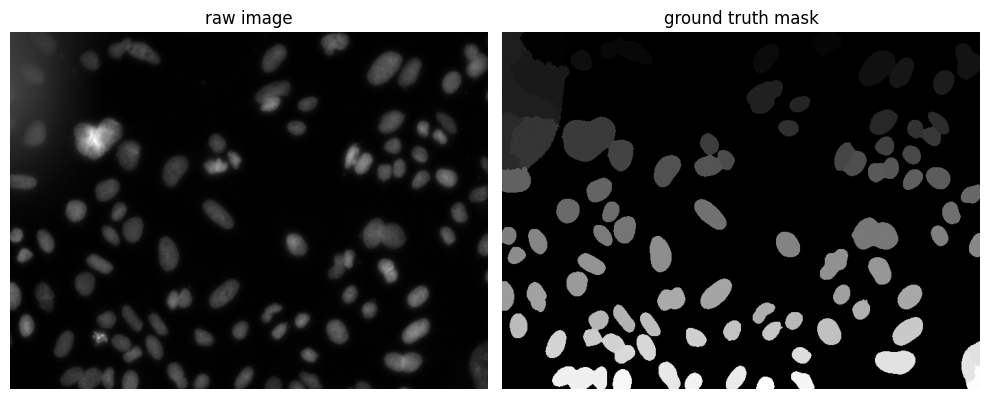

In [ ]:
# %% =========================================================
# cell 9. inspect one sample
# purpose:
# verify that one raw image and one mask load correctly and inspect
# their shape before creating the dataset class
# ============================================================

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

example_row = samples_df.iloc[0]

example_image = np.array(Image.open(example_row["image_path"]))
example_mask = np.array(Image.open(example_row["mask_path"]))

print("example image shape:", example_image.shape, example_image.dtype)
print("example mask shape:", example_mask.shape, example_mask.dtype)
print("unique mask values:", np.unique(example_mask))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(example_image, cmap="gray")
plt.title("raw image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(example_mask, cmap="gray")
plt.title("ground truth mask")
plt.axis("off")

plt.tight_layout()
plt.show()

image_id: bbbc006_o14_s2
source: BBBC006
split: test
image_path: /content/drive/MyDrive/ASR_Project/DATA/combined_dataset/images/bbbc006_o14_s2.png
mask_path: /content/drive/MyDrive/ASR_Project/DATA/combined_dataset/masks/bbbc006_o14_s2.png
image shape: (520, 696) uint8 min/max: 123 255
mask shape: (520, 696) uint8 unique values: [ 0  2  5  8 11 14 17 19 22 25]


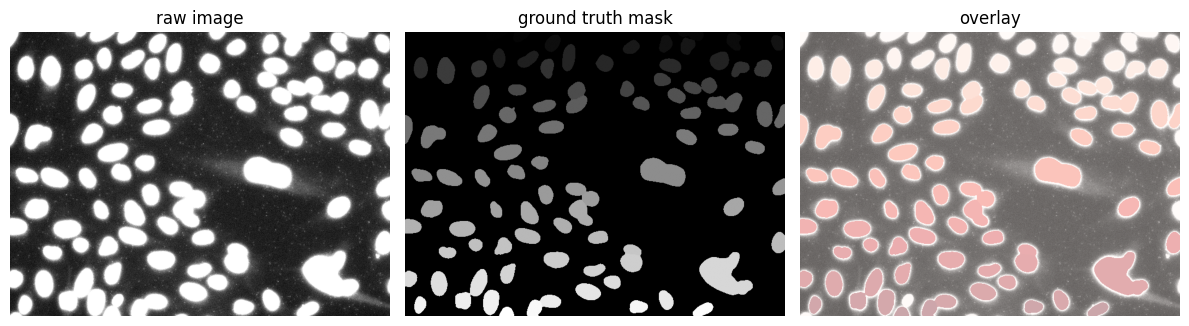

In [ ]:
# %% =========================================================
# debug cell. inspect one sample directly from the csv
# purpose:
# print the file paths and visualize the image and mask together
# to check whether they truly match
# ============================================================

idx = 45   # change this to any suspicious example

row = test_df.iloc[idx]
print("image_id:", row["image_id"])
print("source:", row["source"])
print("split:", row["split"])
print("image_path:", row["image_path"])
print("mask_path:", row["mask_path"])

image = np.array(Image.open(row["image_path"]).convert("L"))
mask = np.array(Image.open(row["mask_path"]).convert("L"))

print("image shape:", image.shape, image.dtype, "min/max:", image.min(), image.max())
print("mask shape:", mask.shape, mask.dtype, "unique values:", np.unique(mask)[:10])

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("raw image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("ground truth mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.35)
plt.title("overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# %% =========================================================
# debug cell. count suspicious images
# purpose:
# find images that are constant, almost blank, or saturated
# ============================================================

rows = []

for i in range(len(samples_df)):
    img = np.array(Image.open(samples_df.iloc[i]["image_path"]).convert("L"))

    rows.append({
        "idx": i,
        "image_id": samples_df.iloc[i]["image_id"],
        "source": samples_df.iloc[i]["source"],
        "split": samples_df.iloc[i]["split"],
        "min": int(img.min()),
        "max": int(img.max()),
        "mean": float(img.mean()),
        "std": float(img.std())
    })

image_stats_df = pd.DataFrame(rows)

constant_images = image_stats_df[image_stats_df["min"] == image_stats_df["max"]]
print("number of constant images:", len(constant_images))
print(constant_images.head(20))

number of constant images: 0
Empty DataFrame
Columns: [idx, image_id, source, split, min, max, mean, std]
Index: []


In [ ]:
# %% =========================================================
# debug cell. summarize extreme image cases
# purpose:
# count all-white and all-black images
# ============================================================

all_white = image_stats_df[(image_stats_df["min"] == 255) & (image_stats_df["max"] == 255)]
all_black = image_stats_df[(image_stats_df["min"] == 0) & (image_stats_df["max"] == 0)]

print("all-white images:", len(all_white))
print("all-black images:", len(all_black))

print("\nexample all-white:")
print(all_white.head())

print("\nexample all-black:")
print(all_black.head())

all-white images: 0
all-black images: 0

example all-white:
Empty DataFrame
Columns: [idx, image_id, source, split, min, max, mean, std]
Index: []

example all-black:
Empty DataFrame
Columns: [idx, image_id, source, split, min, max, mean, std]
Index: []


PIL mode: I;16
raw numpy shape: (520, 696)
raw numpy dtype: uint16


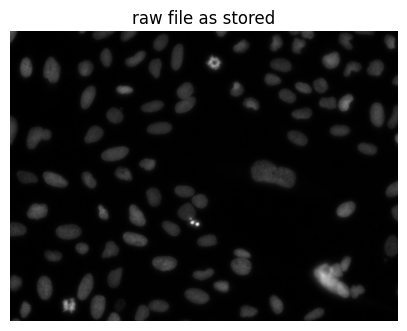

In [ ]:
# %% =========================================================
# debug cell. inspect raw file channels
# purpose:
# see whether the image file has multiple channels or alpha
# ============================================================

idx = 45

row = test_df.iloc[idx]
img_pil = Image.open(row["image_path"])

print("PIL mode:", img_pil.mode)

img_np = np.array(img_pil)
print("raw numpy shape:", img_np.shape)
print("raw numpy dtype:", img_np.dtype)

if img_np.ndim == 3:
    for c in range(img_np.shape[2]):
        print(f"channel {c} min/max:", img_np[..., c].min(), img_np[..., c].max())

plt.figure(figsize=(5,5))
if img_np.ndim == 2:
    plt.imshow(img_np, cmap="gray")
else:
    plt.imshow(img_np)
plt.title("raw file as stored")
plt.axis("off")
plt.show()

In [ ]:
# %% =========================================================
# cell 10. dataset class for segmentation
# purpose:
# load image and mask pairs from the combined dataset while:
# - preserving 16-bit fluorescence intensity when present
# - forcing all images to a single channel
# - forcing all masks to binary single-channel
# - making every returned tensor the same shape
# ============================================================

import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class SegmentationDataset(Dataset):
    def __init__(self, dataframe, image_size=(256, 256)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # -------------------------
        # load image robustly
        # -------------------------
        image = np.array(Image.open(row["image_path"]))

        # if image has multiple channels, reduce to one channel
        if image.ndim == 3:
            image = image[..., 0]

        image = image.astype(np.float32)

        # percentile normalization for fluorescence images
        lo = np.percentile(image, 1)
        hi = np.percentile(image, 99)

        if hi > lo:
            image = np.clip((image - lo) / (hi - lo), 0, 1)
        else:
            image = np.zeros_like(image, dtype=np.float32)

        # resize image after normalization
        image_pil = Image.fromarray((image * 255).astype(np.uint8))
        image = np.array(
            image_pil.resize(self.image_size, Image.BILINEAR),
            dtype=np.float32
        ) / 255.0

        # -------------------------
        # load mask robustly
        # -------------------------
        mask = np.array(Image.open(row["mask_path"]))

        # if mask has multiple channels, reduce to one channel
        if mask.ndim == 3:
            mask = mask[..., 0]

        mask = mask.astype(np.float32)

        # convert mask to binary
        mask = (mask > 0).astype(np.float32)

        # resize mask with nearest-neighbor
        mask_pil = Image.fromarray((mask * 255).astype(np.uint8))
        mask = np.array(
            mask_pil.resize(self.image_size, Image.NEAREST),
            dtype=np.float32
        )
        mask = (mask > 0).astype(np.float32)

        # -------------------------
        # add channel dimension
        # -------------------------
        image = np.expand_dims(image, axis=0)   # [1, H, W]
        mask = np.expand_dims(mask, axis=0)     # [1, H, W]

        return {
            "image": torch.tensor(image, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
            "image_id": row["image_id"],
            "source": row["source"],
            "split": row["split"],
            "dataset_index": idx
        }

In [ ]:
# %% =========================================================
# cell 11. create dataset objects
# purpose:
# create PyTorch dataset objects for train, validation, and test
# ============================================================

train_dataset = SegmentationDataset(train_df, image_size=(256, 256))
val_dataset = SegmentationDataset(val_df, image_size=(256, 256))
test_dataset = SegmentationDataset(test_df, image_size=(256, 256))

print("train dataset size:", len(train_dataset))
print("val dataset size:", len(val_dataset))
print("test dataset size:", len(test_dataset))

train dataset size: 676
val dataset size: 144
test dataset size: 146


image tensor shape: torch.Size([1, 256, 256])
mask tensor shape: torch.Size([1, 256, 256])
image id: bbbc006_p09_s2
source: BBBC006
split: train
dataset index: 0
processed image min/max: 0.0 1.0
processed mask unique values: tensor([0., 1.])


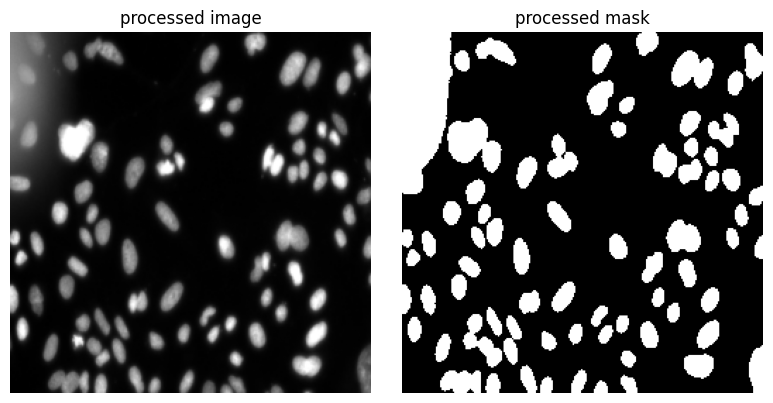

In [ ]:
# %% =========================================================
# cell 12. inspect one processed dataset sample
# purpose:
# verify that the processed tensors have the expected shapes
# and reasonable intensity values
# ============================================================

sample_item = train_dataset[0]

print("image tensor shape:", sample_item["image"].shape)
print("mask tensor shape:", sample_item["mask"].shape)
print("image id:", sample_item["image_id"])
print("source:", sample_item["source"])
print("split:", sample_item["split"])
print("dataset index:", sample_item["dataset_index"])

print("processed image min/max:", sample_item["image"].min().item(), sample_item["image"].max().item())
print("processed mask unique values:", torch.unique(sample_item["mask"]))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_item["image"].squeeze().numpy(), cmap="gray")
plt.title("processed image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_item["mask"].squeeze().numpy(), cmap="gray")
plt.title("processed mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# %% =========================================================
# qc cell. inspect image and mask dimensionality
# purpose:
# find files that are not simple 2D grayscale images
# ============================================================

rows = []

for i in range(len(samples_df)):
    image = np.array(Image.open(samples_df.iloc[i]["image_path"]))
    mask = np.array(Image.open(samples_df.iloc[i]["mask_path"]))

    rows.append({
        "idx": i,
        "image_id": samples_df.iloc[i]["image_id"],
        "image_shape": image.shape,
        "mask_shape": mask.shape,
        "image_ndim": image.ndim,
        "mask_ndim": mask.ndim
    })

shape_df = pd.DataFrame(rows)

print("images with ndim != 2:")
print(shape_df[shape_df["image_ndim"] != 2].head(20))

print("\nmasks with ndim != 2:")
print(shape_df[shape_df["mask_ndim"] != 2].head(20))

images with ndim != 2:
Empty DataFrame
Columns: [idx, image_id, image_shape, mask_shape, image_ndim, mask_ndim]
Index: []

masks with ndim != 2:
    idx           image_id image_shape     mask_shape  image_ndim  mask_ndim
7     7  bbbc039_f04_s5_w1  (520, 696)  (520, 696, 4)           2          3
8     8  bbbc039_i18_s3_w1  (520, 696)  (520, 696, 4)           2          3
13   13  bbbc039_d01_s1_w1  (520, 696)  (520, 696, 4)           2          3
27   27  bbbc039_d07_s4_w1  (520, 696)  (520, 696, 4)           2          3
30   30  bbbc039_h16_s4_w1  (520, 696)  (520, 696, 4)           2          3
34   34  bbbc039_b19_s7_w1  (520, 696)  (520, 696, 4)           2          3
47   47  bbbc039_l14_s5_w1  (520, 696)  (520, 696, 4)           2          3
49   49  bbbc039_b21_s4_w1  (520, 696)  (520, 696, 4)           2          3
52   52  bbbc039_h08_s8_w1  (520, 696)  (520, 696, 4)           2          3
66   66  bbbc039_h24_s6_w1  (520, 696)  (520, 696, 4)           2          3
68   68 

In [ ]:
# %% =========================================================
# qc cell. inspect image and mask dimensionality
# purpose:
# find files that are not simple 2D grayscale images
# ============================================================

rows = []

for i in range(len(samples_df)):
    image = np.array(Image.open(samples_df.iloc[i]["image_path"]))
    mask = np.array(Image.open(samples_df.iloc[i]["mask_path"]))

    rows.append({
        "idx": i,
        "image_id": samples_df.iloc[i]["image_id"],
        "image_shape": image.shape,
        "mask_shape": mask.shape,
        "image_ndim": image.ndim,
        "mask_ndim": mask.ndim
    })

shape_df = pd.DataFrame(rows)

print("images with ndim != 2:")
print(shape_df[shape_df["image_ndim"] != 2].head(20))

print("\nmasks with ndim != 2:")
print(shape_df[shape_df["mask_ndim"] != 2].head(20))

images with ndim != 2:
Empty DataFrame
Columns: [idx, image_id, image_shape, mask_shape, image_ndim, mask_ndim]
Index: []

masks with ndim != 2:
    idx           image_id image_shape     mask_shape  image_ndim  mask_ndim
7     7  bbbc039_f04_s5_w1  (520, 696)  (520, 696, 4)           2          3
8     8  bbbc039_i18_s3_w1  (520, 696)  (520, 696, 4)           2          3
13   13  bbbc039_d01_s1_w1  (520, 696)  (520, 696, 4)           2          3
27   27  bbbc039_d07_s4_w1  (520, 696)  (520, 696, 4)           2          3
30   30  bbbc039_h16_s4_w1  (520, 696)  (520, 696, 4)           2          3
34   34  bbbc039_b19_s7_w1  (520, 696)  (520, 696, 4)           2          3
47   47  bbbc039_l14_s5_w1  (520, 696)  (520, 696, 4)           2          3
49   49  bbbc039_b21_s4_w1  (520, 696)  (520, 696, 4)           2          3
52   52  bbbc039_h08_s8_w1  (520, 696)  (520, 696, 4)           2          3
66   66  bbbc039_h24_s6_w1  (520, 696)  (520, 696, 4)           2          3
68   68 

In [ ]:
# %% =========================================================
# cell 13. indexed subset wrapper and dataloader helper
# purpose:
# preserve original dataset indices when building labeled and
# unlabeled pools for active or passive learning
# ============================================================

from torch.utils.data import Dataset, DataLoader

class IndexedSubset(Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        original_idx = self.indices[i]
        item = self.dataset[original_idx]
        item["dataset_index"] = torch.tensor(original_idx, dtype=torch.long)
        return item


def make_subset_dataloader(dataset, indices, batch_size=4, shuffle=False, num_workers=0):
    subset = IndexedSubset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)

In [ ]:
# %% =========================================================
# cell 14. unet model with dropout
# purpose:
# define the segmentation model used for both active and passive learning
# dropout is included so the same model can support mc dropout
# uncertainty estimation in active learning
# ============================================================

import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256), dropout_p=0.3):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature, dropout_p=dropout_p))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout_p=dropout_p)

        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()

        reversed_features = features[::-1]
        current_in = features[-1] * 2

        for feature in reversed_features:
            self.ups.append(nn.ConvTranspose2d(current_in, feature, kernel_size=2, stride=2))
            self.up_convs.append(DoubleConv(feature + feature, feature, dropout_p=dropout_p))
            current_in = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.ups)):
            x = self.ups[i](x)
            skip = skip_connections[i]

            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            x = torch.cat((skip, x), dim=1)
            x = self.up_convs[i](x)

        return self.final_conv(x)

In [ ]:
# %% =========================================================
# cell 15. loss function and segmentation metrics
# purpose:
# define the training loss and batch-level segmentation metrics
# used during validation and testing
# ============================================================

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        return bce_loss + dice_loss


def compute_batch_metrics(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    intersection = (preds_flat * targets_flat).sum(dim=1)
    union = preds_flat.sum(dim=1) + targets_flat.sum(dim=1) - intersection

    dice = ((2 * intersection + smooth) / (preds_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)).mean().item()
    iou = ((intersection + smooth) / (union + smooth)).mean().item()

    return {"dice": dice, "iou": iou}

In [ ]:
# %% =========================================================
# cell 16. evaluation and training functions
# purpose:
# define reusable functions for:
# - evaluating the model on validation/test loaders
# - training the segmentation model for several epochs
# ============================================================

def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)
            metrics = compute_batch_metrics(logits, masks)

            total_loss += loss.item()
            total_dice += metrics["dice"]
            total_iou += metrics["iou"]
            n_batches += 1

    return {
        "loss": total_loss / max(n_batches, 1),
        "dice": total_dice / max(n_batches, 1),
        "iou": total_iou / max(n_batches, 1)
    }


def train_segmentation_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=5,
    lr=1e-3,
    save_path="best_model.pt"
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = BCEDiceLoss()

    best_val_loss = float("inf")
    history = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        n_train_batches = 0

        for batch in train_loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            n_train_batches += 1

        train_loss = running_train_loss / max(n_train_batches, 1)
        val_metrics = evaluate(model, val_loader, loss_fn, device)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"]
        })

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=device))
    history_df = pd.DataFrame(history)

    return model, history_df

In [ ]:
# %% =========================================================
# cell 17. active/passive learning pool helpers
# purpose:
# create the initial labeled/unlabeled split and update the pools
# after each selection round
# ============================================================

def initialize_active_learning_split(train_dataset, initial_labeled_size=20, seed=42):
    rng = np.random.default_rng(seed)
    all_indices = np.arange(len(train_dataset))
    rng.shuffle(all_indices)

    initial_labeled_size = min(initial_labeled_size, len(all_indices))

    labeled_indices = all_indices[:initial_labeled_size].tolist()
    unlabeled_indices = all_indices[initial_labeled_size:].tolist()

    return labeled_indices, unlabeled_indices


def update_active_learning_pools(labeled_indices, unlabeled_indices, selected_indices):
    selected_set = set(selected_indices)

    labeled_indices = labeled_indices + [idx for idx in selected_indices if idx not in labeled_indices]
    unlabeled_indices = [idx for idx in unlabeled_indices if idx not in selected_set]

    return labeled_indices, unlabeled_indices

In [ ]:
# %% =========================================================
# cell 18. monte carlo dropout helper functions
# purpose:
# define the functions needed for dropout-based uncertainty:
# - keep dropout active during inference
# - run multiple stochastic predictions
# - summarize disagreement as image-level uncertainty
# ============================================================

def enable_dropout(model):
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            module.train()


@torch.no_grad()
def mc_dropout_predictions(model, image_tensor, device, num_samples=10):
    model.eval()
    enable_dropout(model)

    image_tensor = image_tensor.to(device)
    preds = []

    for _ in range(num_samples):
        logits = model(image_tensor)
        probs = torch.sigmoid(logits)
        preds.append(probs.cpu())

    preds = torch.stack(preds, dim=0)
    return preds


def compute_image_uncertainty(mc_preds):
    pixel_variance = torch.var(mc_preds, dim=0)
    image_uncertainty = pixel_variance.mean(dim=(1, 2, 3))
    return image_uncertainty.numpy()

In [ ]:
# %% =========================================================
# cell 19. score the unlabeled pool
# purpose:
# compute uncertainty scores for every image in the current
# unlabeled pool so the most uncertain images can be selected next
# ============================================================

def score_unlabeled_pool(model, unlabeled_loader, device, num_mc_samples=10):
    results = []
    total_batches = len(unlabeled_loader)

    for batch_idx, batch in enumerate(unlabeled_loader):
        if batch_idx % 10 == 0 or batch_idx == total_batches - 1:
            print(f"Scoring unlabeled batch {batch_idx + 1}/{total_batches}")

        images = batch["image"].to(device)
        dataset_indices = batch["dataset_index"]
        image_ids = batch["image_id"]

        mc_preds = mc_dropout_predictions(
            model=model,
            image_tensor=images,
            device=device,
            num_samples=num_mc_samples
        )

        uncertainty_scores = compute_image_uncertainty(mc_preds)

        for i in range(len(uncertainty_scores)):
            results.append({
                "dataset_index": int(dataset_indices[i].item()),
                "image_id": image_ids[i],
                "uncertainty_score": float(uncertainty_scores[i])
            })

    return pd.DataFrame(results)


def select_top_k_uncertain(uncertainty_df, k):
    if uncertainty_df is None or len(uncertainty_df) == 0:
        return pd.DataFrame(columns=["dataset_index", "image_id", "uncertainty_score"])

    if "uncertainty_score" not in uncertainty_df.columns:
        return pd.DataFrame(columns=["dataset_index", "image_id", "uncertainty_score"])

    selected_df = uncertainty_df.sort_values(
        by="uncertainty_score",
        ascending=False
    ).head(k).reset_index(drop=True)

    return selected_df

In [ ]:
# %% =========================================================
# cell 20. one active learning round
# purpose:
# perform one full round of active learning:
# - train on the current labeled set
# - score the unlabeled pool with mc dropout
# - select the top-k most uncertain images
# ============================================================

def run_active_learning_round(
    train_dataset,
    val_dataset,
    labeled_indices,
    unlabeled_indices,
    device,
    selection_batch_size=10,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    num_mc_samples=5,
    dropout_p=0.3,
    model_save_path="active_round_best_model.pt"
):
    model = UNet(in_channels=1, out_channels=1, dropout_p=dropout_p).to(device)

    labeled_loader = make_subset_dataloader(
        dataset=train_dataset,
        indices=labeled_indices,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=train_batch_size,
        shuffle=False,
        num_workers=0
    )

    model, history = train_segmentation_model(
        model=model,
        train_loader=labeled_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=num_epochs,
        lr=lr,
        save_path=model_save_path
    )

    if len(unlabeled_indices) == 0:
        empty_df = pd.DataFrame(columns=["dataset_index", "image_id", "uncertainty_score"])
        return model, history, empty_df, empty_df, []

    unlabeled_loader = make_subset_dataloader(
        dataset=train_dataset,
        indices=unlabeled_indices,
        batch_size=train_batch_size,
        shuffle=False,
        num_workers=0
    )

    uncertainty_df = score_unlabeled_pool(
        model=model,
        unlabeled_loader=unlabeled_loader,
        device=device,
        num_mc_samples=num_mc_samples
    )

    selected_df = select_top_k_uncertain(
        uncertainty_df,
        k=min(selection_batch_size, len(unlabeled_indices))
    )

    selected_indices = selected_df["dataset_index"].tolist() if len(selected_df) > 0 else []

    return model, history, uncertainty_df, selected_df, selected_indices

In [ ]:
# %% =========================================================
# cell 21. full active learning loop
# purpose:
# repeat multiple active learning rounds on the training set and
# track:
# - current labeled size
# - current unlabeled size
# - uncertainty of selected images
# - test performance after each round
# ============================================================

def active_learning_loop(
    train_dataset,
    val_dataset,
    test_dataset,
    device,
    initial_labeled_size=20,
    selection_batch_size=10,
    num_rounds=3,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    num_mc_samples=5,
    dropout_p=0.3,
    seed=42
):
    labeled_indices, unlabeled_indices = initialize_active_learning_split(
        train_dataset=train_dataset,
        initial_labeled_size=initial_labeled_size,
        seed=seed
    )

    round_history = []
    final_model = None

    for round_idx in range(num_rounds):
        print(f"\n=== Active Learning Round {round_idx + 1}/{num_rounds} ===")
        print("Current labeled size:", len(labeled_indices))
        print("Current unlabeled size:", len(unlabeled_indices))

        model, train_history_df, uncertainty_df, selected_df, selected_indices = run_active_learning_round(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            labeled_indices=labeled_indices,
            unlabeled_indices=unlabeled_indices,
            device=device,
            selection_batch_size=selection_batch_size,
            train_batch_size=train_batch_size,
            num_epochs=num_epochs,
            lr=lr,
            num_mc_samples=num_mc_samples,
            dropout_p=dropout_p,
            model_save_path=f"active_round_{round_idx + 1}_best_model.pt"
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=train_batch_size,
            shuffle=False,
            num_workers=0
        )

        loss_fn = BCEDiceLoss()
        test_metrics = evaluate(model, test_loader, loss_fn, device)

        round_history.append({
            "round": round_idx + 1,
            "labeled_size": len(labeled_indices),
            "unlabeled_size": len(unlabeled_indices),
            "num_selected_this_round": len(selected_indices),
            "mean_selected_uncertainty": selected_df["uncertainty_score"].mean() if len(selected_df) > 0 else np.nan,
            "test_loss": test_metrics["loss"],
            "test_dice": test_metrics["dice"],
            "test_iou": test_metrics["iou"]
        })

        labeled_indices, unlabeled_indices = update_active_learning_pools(
            labeled_indices=labeled_indices,
            unlabeled_indices=unlabeled_indices,
            selected_indices=selected_indices
        )

        final_model = model

        if len(unlabeled_indices) == 0:
            print("unlabeled pool is empty, stopping early")
            break

    round_history_df = pd.DataFrame(round_history)
    return final_model, round_history_df, labeled_indices, unlabeled_indices

In [ ]:
# %% =========================================================
# cell 22. run the active learning experiment
# purpose:
# execute an active learning run using the train split of the
# new combined dataset
# ============================================================

active_model, active_history_df, final_labeled_indices, final_unlabeled_indices = active_learning_loop(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    device=DEVICE,
    initial_labeled_size=20,
    selection_batch_size=10,
    num_rounds=3,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    num_mc_samples=5,
    dropout_p=0.3,
    seed=SEED
)

print("\nactive learning history:")
print(active_history_df)


=== Active Learning Round 1/3 ===
Current labeled size: 20
Current unlabeled size: 656
Epoch 1/5 | Train Loss: 1.2087 | Val Loss: 1.3371 | Val Dice: 0.0139 | Val IoU: 0.0139
Epoch 2/5 | Train Loss: 1.0502 | Val Loss: 1.2677 | Val Dice: 0.0965 | Val IoU: 0.0606
Epoch 3/5 | Train Loss: 0.9150 | Val Loss: 1.1650 | Val Dice: 0.2449 | Val IoU: 0.1444
Epoch 4/5 | Train Loss: 0.9146 | Val Loss: 1.0152 | Val Dice: 0.6389 | Val IoU: 0.4788
Epoch 5/5 | Train Loss: 0.8673 | Val Loss: 0.8925 | Val Dice: 0.8293 | Val IoU: 0.7208
Scoring unlabeled batch 1/164
Scoring unlabeled batch 11/164
Scoring unlabeled batch 21/164
Scoring unlabeled batch 31/164
Scoring unlabeled batch 41/164
Scoring unlabeled batch 51/164
Scoring unlabeled batch 61/164
Scoring unlabeled batch 71/164
Scoring unlabeled batch 81/164
Scoring unlabeled batch 91/164
Scoring unlabeled batch 101/164
Scoring unlabeled batch 111/164
Scoring unlabeled batch 121/164
Scoring unlabeled batch 131/164
Scoring unlabeled batch 141/164
Scoring 

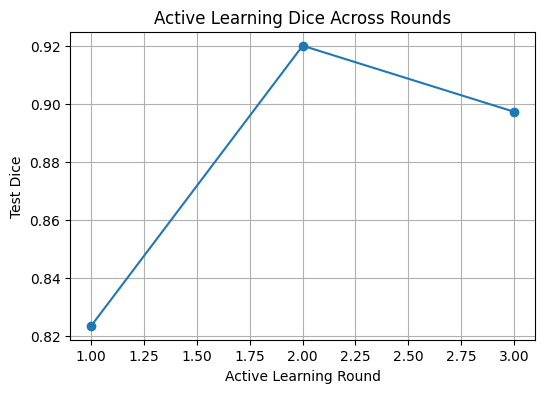

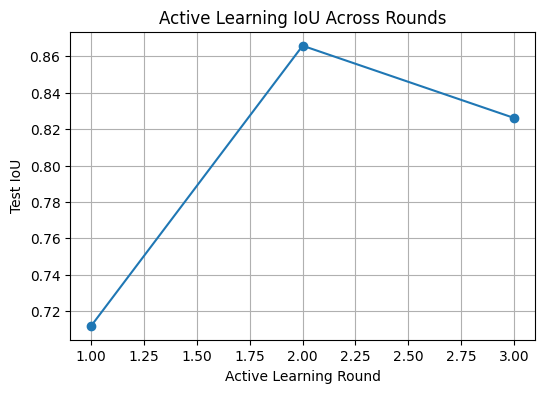

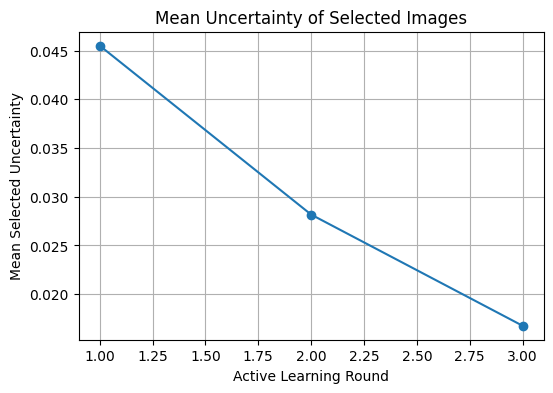

In [ ]:
# %% =========================================================
# cell 23. visualize active learning performance
# purpose:
# plot how segmentation performance changes across active learning
# rounds
# ============================================================

if len(active_history_df) > 0:
    plt.figure(figsize=(6, 4))
    plt.plot(active_history_df["round"], active_history_df["test_dice"], marker="o")
    plt.xlabel("Active Learning Round")
    plt.ylabel("Test Dice")
    plt.title("Active Learning Dice Across Rounds")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(active_history_df["round"], active_history_df["test_iou"], marker="o")
    plt.xlabel("Active Learning Round")
    plt.ylabel("Test IoU")
    plt.title("Active Learning IoU Across Rounds")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(active_history_df["round"], active_history_df["mean_selected_uncertainty"], marker="o")
    plt.xlabel("Active Learning Round")
    plt.ylabel("Mean Selected Uncertainty")
    plt.title("Mean Uncertainty of Selected Images")
    plt.grid(True)
    plt.show()

In [ ]:
# %% =========================================================
# cell 24. inspect final active learning summary
# purpose:
# print a compact summary of the active learning experiment
# ============================================================

print("final labeled size:", len(final_labeled_indices))
print("final unlabeled size:", len(final_unlabeled_indices))

print("\nactive learning round summary:")
print(
    active_history_df[
        [
            "round",
            "labeled_size",
            "unlabeled_size",
            "num_selected_this_round",
            "mean_selected_uncertainty",
            "test_loss",
            "test_dice",
            "test_iou"
        ]
    ]
)

final labeled size: 50
final unlabeled size: 626

active learning round summary:
   round  labeled_size  unlabeled_size  num_selected_this_round  \
0      1            20             656                       10   
1      2            30             646                       10   
2      3            40             636                       10   

   mean_selected_uncertainty  test_loss  test_dice  test_iou  
0                   0.045509   0.880324   0.823622  0.712002  
1                   0.028169   0.683500   0.919968  0.865834  
2                   0.016757   0.590501   0.897254  0.826153  


In [ ]:
# %% =========================================================
# cell 25. visualize predicted masks for active learning
# purpose:
# show raw image, ground truth mask, and predicted mask side by side
# for a few examples from the test dataset
# ============================================================

def visualize_predictions(model, dataset, device, num_examples=5, threshold=0.5):
    model.eval()

    if len(dataset) == 0:
        print("dataset is empty")
        return

    num_examples = min(num_examples, len(dataset))
    indices = np.random.choice(len(dataset), size=num_examples, replace=False)

    fig, axes = plt.subplots(num_examples, 3, figsize=(10, 4 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, dataset_idx in enumerate(indices):
            sample = dataset[dataset_idx]

            image_tensor = sample["image"].unsqueeze(0).to(device)
            raw_image = sample["image"].squeeze().cpu().numpy()
            true_mask = sample["mask"].squeeze().cpu().numpy()

            logits = model(image_tensor)
            probs = torch.sigmoid(logits)
            pred_mask = (probs > threshold).float().squeeze().cpu().numpy()

            axes[row_idx, 0].imshow(raw_image, cmap="gray")
            axes[row_idx, 0].set_title(f"Raw Image\nindex={dataset_idx}")
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(true_mask, cmap="gray")
            axes[row_idx, 1].set_title("Ground Truth Mask")
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(pred_mask, cmap="gray")
            axes[row_idx, 2].set_title("Predicted Mask")
            axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()

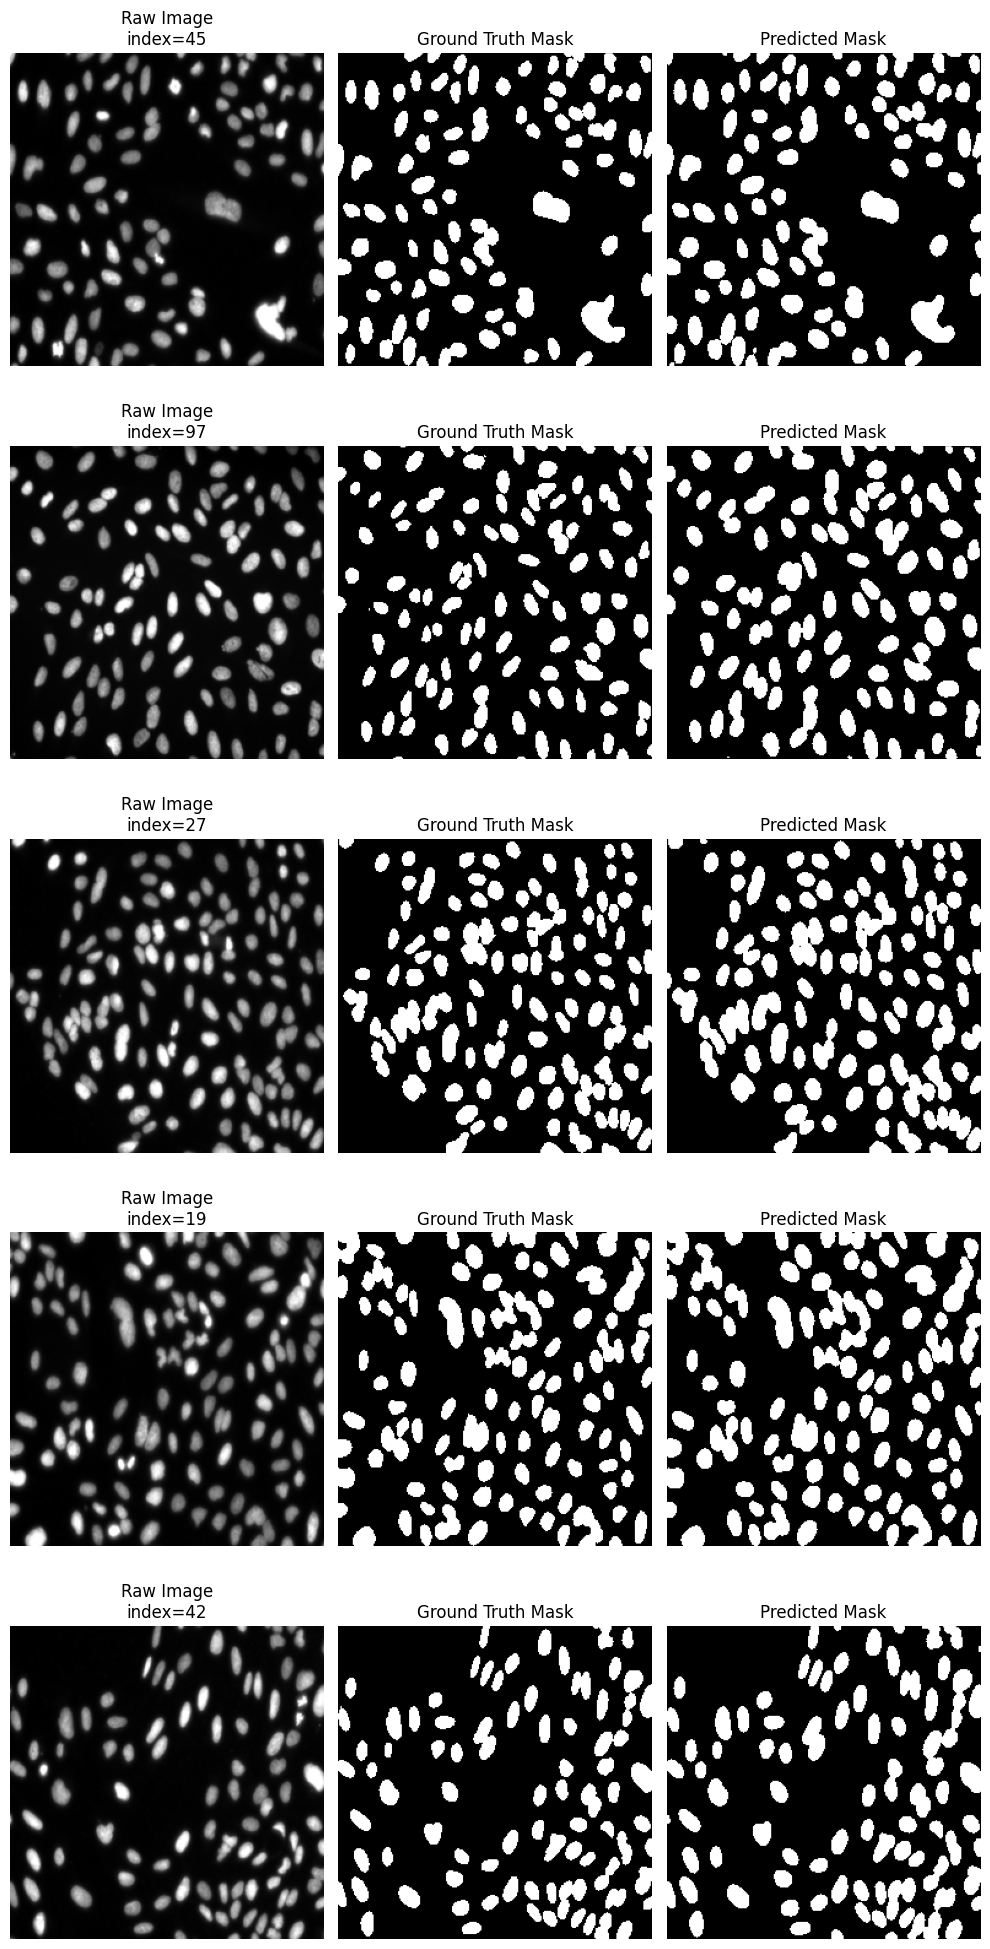

In [ ]:
visualize_predictions(active_model, test_dataset, DEVICE, num_examples=5, threshold=0.5)